## 0.  MOTIVATION

We examine the data in `bank-additional-full.csv`, the public data associated with the paper `"A data-driven approach to predict the success of bank telemarketing"` by S.Moro, P.Cortez,P.Rita (2014), DOI:10.1016/j.dss.2014.03.001. The authors predict the **success of telemarketing calls for selling bank long-term
deposits for a Portuguese bank. A specific point we want to investigate is if the inclusion of macro socio-economic features in the models improves models' performances also using this dataset (which is **different** from the one used in the paper).

### Differences with the original paper

The data used in the paper are collected from 2008 to 2013, ordered by date. The initial dataset contained 150 features related to bank client, product and social-economic attributes, but the authors managed to isolate 20 features which are sufficient for accurately predicting the success rate, i.e. if the client would subscribe a contract for a long-term deposit. This reduced dataset used in the paper is similar to `bank-additional-full.csv` which we use in this notebook, with two crucial differences:

 - Some features are different. For instance, we do not have features related to the agent experience, the client-bank relationship and the details on the interest rate.
  - We **only have data from May 2008 to November 2010** missing roughly 3 years of data compared to the data in the paper. As a cnsequence we have fewer data: 41.188 rows vs  52.944 rows.

Our notebook is thus **not a replication** of the results in the paper and the two are not comparable. We remark that we follow the advice in the .txt file documenting our dataset: we drop the feature `duration` (i.e. the duration of a phone call) since it is not known a priori before making the call. We also rename the target from `y` to `deposit` for clarity.

## Methodology

We investigate the results obtained by ML algorithms under different assumptions:

1. **How the data are split.** The rows are ordered by date, so a *chronological* split trains on the past and tests on the future, while a *random* split mixes them. We report both, and the gap between them is the main finding of the notebook.
2. **`duration` in or out.** The documentation is explicit that this attribute (the length of the call) is only known once the call is over, so it cannot inform the decision to make it. It is excluded from every model we would deploy, and kept **only as a benchmark**, so that what it was worth can be measured rather than asserted.
3. **The five macro socio-economic features in or out.** This is the paper's claim, and the question the notebook was written to answer.

We remark that, as noted in the documentation of the dataset, `duration` is only known a posteriori and should not be considered in a real, deliverable project since it introduces leakage into the model.
## Results and findings

**The dataset contains two distinct regimes.** Around row 25.000 (roughly November 2008) the success rate rises from 5% to 20%, contact by mobile from 46% to 90%, and the share of clients with a prior contact history from 0,8% to 33%. Section 3 documents this and identifies which features move with it. The last 10% of the file (our test split) subscribes at **45,9%**.

**A model validated against the future is FAR weaker than the same model validated at random.** Section 5 delivers a logistic regression on the whole dataset without `duration` and without the macro features: test ROC-AUC is **0,637** using temporal splits, while the identical pipeline evaluated on a stratified *random* split of the same data scores **0,77–0,80**, which is the band reported by most published analyses of this dataset. Section 5.6 isolates the mechanism: **the macro features recover a row's position in the file with ROC-AUC 0,9999, so a random split rewards a model for reading a timestamp that a chronological cannot.**.

**The macro features do not help.** This is arguably the most surprising finding. When using *temporal splits", their inclusion does not change the models significantly.

**`duration` is worth +0,28 of ROC-AUC**, more than the other twenty features combined, and it is not available when the decision is taken.

Section 5.7 collects the conclusions and the limitations.

## 1. Import necessary packages


In [ ]:
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, confusion_matrix, f1_score)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     TimeSeriesSplit, GridSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin

## 2. Load the dataset and define features and objective sets.


In [ ]:

#Load dataset and rename target column
df = pd.read_csv("bank-additional-full.csv", delimiter=";")
df.rename(columns={'y': "deposit"}, inplace=True)

#Definition of features categories

#The five macro socio-economic features
ECONOMIC = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
#Numerical features
NUMERICAL = ["age", "campaign", "pdays", "previous","duration"] + ECONOMIC
#Categorical features
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan",
               "contact", "month", "day_of_week", "poutcome"]
#All features
FEATURES = NUMERICAL + CATEGORICAL

#Target feature: whether the client subscribed a long-term deposit contract
TARGET = "deposit"

## 3. EDA

### 3.1 Data cleaning
In this case the dataset refers to a published paper, although it is not the one used by the authors, so it would be safe to assume that it is clean. However, it is a good practice never to skip this step.

We refer to `bank-additional-names.txt` for the details on the dataset. As noted in section 0, the raw dataset has 41.188 rows and 20 features (+ 1 target).

We now describe each feature to better understand the setting. Features refer to both

- **"age"**: (Numerical).
- **"job"**: (Categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown").
- **"marital"**: (Categorical: "divorced","married","single","unknown").
- **"education"**: (Categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown").
- **"default"**: Has default credit? (Binary: "yes", "no", "unknown").
- **"housing"**: Has housing loan? (Categorical: "no","yes","unknown").
- **"loan"**: Has personal loan? (Categorical: "no","yes","unknown").
- **"contact"**: Contact communication type (Categorical: "cellular","telephone").
- **"month"**: Last contact month of year (Categorical: "jan", "feb", "mar", ..., "nov", "dec").
- **"day_of_week"**: Last contact day of the week (Categorical: "mon","tue","wed","thu","fri").
- **"duration"**: Last contact duration, in seconds (Numerical). Important note:  this attribute **highly** affects the output target (e.g., if duration=0 then y="no"). Yet, the **duration is not known before a call is performed**. Also, after the end of the call y is obviously known. Thus, **this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model**.
- **"campaign"** : Number of contacts performed during this campaign and for this client (Numerical).
- **"pdays"**: Number of days that passed by after the client was last contacted from a previous campaign (Numerical; 999 means client was not previously contacted).
- **"previous"**: Number of contacts performed before this campaign and for this client (Numerical).
- **"poutcome"**: Outcome of the previous marketing campaign (Categorical: "failure","nonexistent","success").
### social and economic context attributes
- **"emp.var.rate"**: Employment variation rate - quarterly indicator (Numerical).
- **"cons.price.idx"**: Consumer price index - monthly indicator (Numerical).
- **"cons.conf.idx"**: Consumer confidence index - monthly indicator (Numerical).
- **"euribor3m"**: Euribor 3 month rate - daily indicator (Numerical).
- **"nr.employed"**: Number of employees - quarterly indicator (Numerical).
### target
- **"deposit"**: Has the client subscribed a term deposit? (Binary: "yes","no").

In [ ]:
# Check the dimensions of the dataframe

ROWS = 41188
COLS = 21
if df.shape[0] != ROWS or df.shape[1] != COLS:
	warnings.warn("WARNING! Dataframe dimensions inconsistent with the documentation!")
else:
	print(f"The DataFrame has {ROWS} rows and {COLS} columns, as claimed in the .txt documentation file.")

In [ ]:
# Check for heterogeneous entries and missing values

expected = {c: "number" for c in NUMERICAL} | {c: "string" for c in CATEGORICAL}
wrong = [c for c, kind in expected.items()
         if (kind == "number") != pd.api.types.is_numeric_dtype(df[c])]
if wrong:
    warnings.warn(f"WARNING! : unexpected dtype in {wrong}")

s = df.isna().sum().sum()

if s >0:
	warnings.warn(f"WARNING! : There are {s} NaN values in the dataframe.")
else:
	print(f"There are no missing values.")


We now check each feature separately. In order to make sure that no incorrect values appear in the dataset.

In [ ]:
#We check the values of categorical data vs the ones reported in the documentation .txt file. We issue a warning if the values
#appearing in the dataaset are not a subset of the possible values described in the documentation.
POSSIBLE_JOBS = {"admin.", "blue-collar", "entrepreneur", "housemaid", "management", "retired", "self-employed",
                 "services", "student", "technician", "unemployed", "unknown"}
if not set(df["job"].unique()).issubset(POSSIBLE_JOBS):
	warnings.warn("WARNING! : Job type is inconsistent")

POSSIBLE_MARITAL_STATUS = {"divorced", "married", "single", "unknown"}
if not set(df["marital"].unique()).issubset(POSSIBLE_MARITAL_STATUS):
	warnings.warn("WARNING! : Marital status is inconsistent")

EDUCATION = {"basic.4y", "basic.6y", "basic.9y", "high.school", "illiterate", "professional.course",
             "university.degree", "unknown"}
if not set(df["education"].unique()).issubset(EDUCATION):
	warnings.warn("WARNING! : Education is inconsistent")

POSSIBLE_DEFAULT = {"yes", "no", "unknown"}
if not set(df["default"].unique()).issubset(POSSIBLE_DEFAULT):
	warnings.warn("WARNING! : Default type is inconsistent")

POSSIBLE_HOUSING = {"yes", "no", "unknown"}
if not set(df["housing"].unique()).issubset(POSSIBLE_HOUSING):
	warnings.warn("WARNING! : Housing type is inconsistent")

POSSIBLE_LOAN = {"yes", "no", "unknown"}
if not set(df["loan"].unique()).issubset(POSSIBLE_LOAN):
	warnings.warn("WARNING! : Loan type is inconsistent")

POSSIBLE_CONTACT = {"cellular", "telephone"}
if not set(df["contact"].unique()).issubset(POSSIBLE_CONTACT):
	warnings.warn("WARNING! : Contact type is inconsistent")

POSSIBLE_MONTH = {"jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"}
if not set(df["month"].unique()).issubset(POSSIBLE_MONTH):
	warnings.warn("WARNING! : Month type is inconsistent")

POSSIBLE_DAY_OF_WEEK = {"mon", "tue", "wed", "thu", "fri"}
if not set(df["day_of_week"].unique()).issubset(POSSIBLE_DAY_OF_WEEK):
	warnings.warn("WARNING! : Day_of_week type is inconsistent")

POSSIBLE_POUTCOME = {"failure", "nonexistent", "success"}
if not set(df["poutcome"].unique()).issubset(POSSIBLE_POUTCOME):
	warnings.warn("WARNING! : Poutcome type is inconsistent")

#We check that the numerical features related to contacts are non-negative, with pdays additionally admitting the sentinel value 999.
if ((df["age"]<0) | (df["age"]>=130)).sum() >0:
	warnings.warn("WARNING! Age values are inconsistent")

elif (df["campaign"]<0).sum() >0:
	warnings.warn("WARNING! Campaign values are inconsistent")

elif ((df["pdays"]<0) | (df["pdays"]>999)).sum() >0:
	warnings.warn("WARNING! Pdays values are inconsistent")

elif (df["previous"]<0).sum() >0:
	warnings.warn("WARNING! Previous values are inconsistent")

elif (df["duration"]<0).sum() >0:
	warnings.warn("WARNING! Duration values are inconsistent")

else:
    print("All categorical and contact-related numerical features are consistent with the documentation.")


In [ ]:
#Finally, we check the five social and economic context attributes and the target.

#These are quarterly/monthly/daily indicators, so we only check that they are finite numbers, without imposing hard bounds (unlike the other numerical features, there is no documented valid range for them).
if not np.isfinite(df[ECONOMIC]).all().all():
	warnings.warn("WARNING! : There are non-finite values among the economic/social features")

#euribor3m and nr.employed are, respectively, an interest rate and a headcount, so they must be strictly positive.
if (df["euribor3m"]<=0).sum() >0:
	warnings.warn("WARNING! Euribor3m values are inconsistent")

if (df["nr.employed"]<=0).sum() >0:
	warnings.warn("WARNING! Nr.employed values are inconsistent")

#Lastly, we check the target: the client either subscribed a deposit or did not.
POSSIBLE_DEPOSIT = {"yes", "no"}
if set(df[TARGET].tolist()) != POSSIBLE_DEPOSIT:
	warnings.warn("WARNING! : Deposit (target) type is inconsistent")
else:
	print("\nAll economic/social features are finite and consistent, and the target is binary as expected.")

Now that we are sure the data is clean, we can start with the real EDA. We focus first on numerical features, and later on categorical ones.


### 3.2 EDA on numerical features

 The documentation states that **"pdays" = 999** means "the client was not previously contacted". This is **not** what the column contains. 4110 rows have **"pdays" = 999** together with **"previous" > 0** and **"poutcome" = "failure"**: clients who were contacted in an earlier campaign, but whose time gap was never recorded. The sentinel therefore means **"gap unknown"**, not **"never contacted"**.

Two distinct facts are hiding in three columns, so we check and encode them separately:

 - **Ever contacted before**: carried by "previous" and "poutcome", which agree on every row. We verify this, and add no new feature: one-hot encoding "poutcome" already supplies the indicator.
 - **Time since last contact is known**: carried by "pdays" alone. This becomes "recent_contact", the missing-value indicator for "pdays".

In [ ]:
NO_PREV = 999 #placeholder in pdays: gap unknown, NOT "never contacted"

#previous and poutcome both encode "contacted in a previous campaign": they must agree.
if ((df["previous"]==0) != (df["poutcome"] == "nonexistent")).any():
    warnings.warn("WARNING! : previous and poutcome disagree on whether the client was contacted before.")
else:
    print("Values of previous and poutcome agree on every row.")

rows_pdays = (df["pdays"] == NO_PREV)
print(f"{(rows_pdays & (df['previous']>0)).sum()} rows were previously contacted but have pdays={NO_PREV}.")



In [ ]:
BAR_COLOR = "#2a78d6"       # single sequential hue for the bars
MEDIAN_COLOR = "#0b0b0b"    # primary ink
QUANTILE_COLOR = "#898781"  # muted ink
GRID_COLOR = "#e1e0d9"      # hairline gridline
AXIS_COLOR = "#c3c2b7"      # baseline/axis


def value_aligned_bins(values, max_bins=100, max_unique=250, rtol=1e-6):
    #Returns bin edges of constant width, each bin centred on one distinct value, when the distinct
    #values lie on a regular lattice (all gaps integer multiples of the smallest). The bin width is
    #that smallest gap; gaps in the lattice become empty bins.
    #Returns "auto" when the values are not on a lattice, when there are more than `max_unique`
    #distinct values, or when the lattice would need more than `max_bins` bins.
    uniques = np.unique(np.asarray(values, dtype=float))
    uniques = uniques[np.isfinite(uniques)]

    if uniques.size == 0:
        return "auto"
    if uniques.size == 1:
        return np.array([uniques[0] - 0.5, uniques[0] + 0.5])
    if uniques.size > max_unique:
        return "auto"

    gaps = np.diff(uniques)
    step = gaps.min()
    if step <= 0:
        return "auto"

    multiples = gaps / step
    if not np.allclose(multiples, np.round(multiples), rtol=rtol, atol=1e-9):
        return "auto"

    n_bins = int(round((uniques[-1] - uniques[0]) / step)) + 1
    if n_bins > max_bins:
        return "auto"

    return uniques[0] - step / 2 + step * np.arange(n_bins + 1)


n_rows = n_cols = int(np.ceil(np.sqrt(len(NUMERICAL))))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, NUMERICAL):
    data = df[col].dropna()
    bins = value_aligned_bins(data.values)
    ax.hist(data, bins=bins, color=BAR_COLOR, edgecolor="white", linewidth=0.4, zorder=2)

    q1, median, q3 = data.quantile([0.25, 0.5, 0.75])
    ax.axvline(median, color=MEDIAN_COLOR, linestyle="-", linewidth=1.5, zorder=3, label="Median")
    ax.axvline(q1, color=QUANTILE_COLOR, linestyle="--", linewidth=1.2, zorder=3, label="Q1 / Q3")
    ax.axvline(q3, color=QUANTILE_COLOR, linestyle="--", linewidth=1.2, zorder=3)

    ax.set_title(col, fontsize=11, color="#0b0b0b")
    ax.set_xlabel(col, fontsize=9, color="#0b0b0b")
    ax.set_ylabel("Count", fontsize=9, color="#0b0b0b")
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)

#Remove any unused axes (if the grid has more cells than features).
for ax in axes[len(NUMERICAL):]:
    fig.delaxes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.03), fontsize=10)
fig.suptitle("Distributions of numerical features", fontsize=14, y=1.06)
fig.tight_layout()
plt.show()

We learn a few things from a simple visual inspection of the data:
- The campaign mostly targets people between 30 and 40, with a sharp drop after 60.
- Most people are contacted either once or twice at most.
- When people are contacted again, this usually happens before a week.
- Most people in this campaign were never contacted by previous ones.

The economic and social features (i.e. the last five ones) are scattered and do not give any immediate insight.

We now consider the correlation between numerical features.



In [ ]:
plt.figure(figsize=(16, 16))
sns.heatmap(df[NUMERICAL].corr(method='pearson', min_periods=1),cmap="YlGnBu",annot = True)

### 3.3 EDA on categorical features

In [ ]:
#Ordinal scales contain only real levels. A missingness code has no position on the scale,
#so it is kept out of the ordering and drawn in a muted colour after a separator.
NATURAL_ORDER = {
    "education": ["illiterate", "basic.4y", "basic.6y", "basic.9y",
                  "high.school", "professional.course", "university.degree"],
    "month": MONTHS,
    "day_of_week": ["mon", "tue", "wed", "thu", "fri"],
}
NOT_A_LEVEL = {"unknown", "nonexistent"}
MISSING_COLOR = "#b8b6ad"

n_cols = 2
n_rows = int(np.ceil(len(CATEGORICAL) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 2.4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, CATEGORICAL):
    counts = df[col].value_counts()

    if col in NATURAL_ORDER:
        #Declared levels that occur, then everything else (missingness codes, or a level
        #I forgot to declare) appended so nothing can be silently dropped.
        order = [l for l in NATURAL_ORDER[col] if l in counts.index]
        order += [l for l in counts.index if l not in order]
        note = "natural order"
    else:
        order = list(counts.sort_values().index)
        note = "by frequency"

    order  = order[::-1]                     #reverse ONCE: barh draws index 0 at the bottom
    counts = counts.reindex(order)           #both counts and colours now follow `order`
    colors = [MISSING_COLOR if l in NOT_A_LEVEL else BAR_COLOR for l in order]

    ax.barh(counts.index.astype(str), counts.values, color=colors, height=0.68, zorder=2)
    for level, n in counts.items():
        ax.text(n + 0.006 * len(df), str(level), f"{100 * n / len(df):.1f}%",
                va="center", fontsize=7, color=QUANTILE_COLOR)

    #Separator between the ordinal scale and the codes that are not on it.
    n_missing = sum(l in NOT_A_LEVEL for l in order)
    if col in NATURAL_ORDER and n_missing:
        ax.axhline(n_missing - 0.5, color=AXIS_COLOR, lw=0.9, ls="--", zorder=1)

    ax.set_title(f"{col} - {len(counts)} levels ({note})", fontsize=10, loc="left", color="#0b0b0b")
    ax.set_xlabel("Count", fontsize=9, color="#0b0b0b")
    ax.set_xlim(0, counts.max() * 1.18)
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)

for ax in axes[len(CATEGORICAL):]:
    fig.delaxes(ax)

fig.suptitle("Occurrences of categorical features  (grey = missingness code, not a level)",
             fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

## Time dependent EDA

As we already mentioned, the dataset is implicitly ordered with respect to time. Thus, after the analysis just performed we now consider a EDA taking into account the fact that statistics may change with respect to time. By far, the strongest signal that time is a crucial feature in the model is the percentage of positive outcomes (i.e. of people signing a long-term deposit contract), averaged over a 1000 rows window.

In [ ]:
BLOCK = 1000
THRESHOLD = 25000
fig, ax = plt.subplots(figsize=(10, 4))
x, rate = [], []
for start in range(0, len(df), BLOCK) :
	block = df["deposit"][start : start + BLOCK]
	yes = (block == "yes").sum()
	tot = len(block)
	x.append(start)
	rate.append(100 * yes / tot)
ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4)
ax.set_xticks(x[: :5])
ax.set_xlabel("Rows (Time)")
ax.set_ylabel("Percentage of successfull calls")
plt.plot(x, rate)
plt.show()

We now repeat this per-feature, reusing the same `BLOCK` size and the same 25000-row split, to see whether individual numerical and categorical features drift over time as well, or whether the shift is confined to the target rate. We do not group **"months"** in blocks of size 1000 in order to show hw the dataset is ordered in time (from May 2008 to November 2010 in particular) and how the second half of the year 2008 is predominant in the dataset.

In [ ]:
#For each categorical feature, we compute, per block of BLOCK rows, the percentage of rows
#falling in each level (i.e. the block-average of the one-hot indicator of that level).
#tab20 is 10 (dark, light) PAIRS: index it, saturated half first, instead of interpolating
#it with linspace (which lands on both halves of a pair and yields duplicate hues).

NO_BLOCK_COLS = {"month"}  # Columns where we plot the vaues of each row, without grouping them beforehand

_t20 = plt.get_cmap("tab20").colors
PALETTE = list(_t20[0::2]) + list(_t20[1::2])

n_cols = 2
n_rows = int(np.ceil(len(CATEGORICAL) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9.5 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, CATEGORICAL):
    uniques = df[col].unique()
    #Case 1: No blocks
    if col in NO_BLOCK_COLS:
        if col == "month":
            MONTHS = ["jan", "feb", "mar", "apr", "may", "jun",
                      "jul", "aug", "sep", "oct", "nov", "dec"]
            mnum = df["month"].map({m: i for i, m in enumerate(MONTHS, 1)})

            ax.plot(np.arange(len(df)), mnum, lw=1.2, color="#0b0b0b")
            ax.set_yticks(range(1, 13))
            ax.set_yticklabels(MONTHS)
            ax.set_xlabel("Rows (Time)", fontsize=9, color="#0b0b0b")
            ax.set_ylabel("month", fontsize=9, color="#0b0b0b")
            ax.set_ylim(0.4, 12.6)

            ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4, zorder=3)

            ax.set_title(col, fontsize=11, color="#0b0b0b")
            ax.tick_params(labelsize=8, colors="#0b0b0b")
            ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
            ax.set_axisbelow(True)
            for spine in ("top", "right"):
                ax.spines[spine].set_visible(False)
            for spine in ("left", "bottom"):
                ax.spines[spine].set_color(AXIS_COLOR)
            continue

    #Case 2: with blocks
    if col in NATURAL_ORDER:
        levels = [l for l in NATURAL_ORDER[col] if l in uniques]
        levels += [l for l in uniques if l not in levels]
    else:
        levels = list(df[col].value_counts().index)

    colors = [PALETTE[i % len(PALETTE)] for i in range(len(levels))]

    x = []
    pct = {lvl: [] for lvl in levels}
    for start in range(0, len(df), BLOCK):
        block = df[col].iloc[start : start + BLOCK]
        tot = len(block)
        if tot < BLOCK // 2:          # skip the ragged final block
            continue
        x.append(start)
        for lvl in levels:
            pct[lvl].append(100 * (block == lvl).sum() / tot)

    for lvl, color in zip(levels, colors):
        ax.plot(x, pct[lvl], color=color, linewidth=1.2, label=str(lvl))

    ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4, zorder=3)

    ax.set_title(col, fontsize=11, color="#0b0b0b")
    ax.set_xlabel("Rows (Time)", fontsize=9, color="#0b0b0b")
    ax.set_ylabel("Percentage of block", fontsize=9, color="#0b0b0b")
    ax.set_ylim(-2, 102)
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)
    ax.legend(
        fontsize=7,
        ncol=1 if len(levels) <= 6 else 2,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
    )

# Remove any unused axes
for ax in axes[len(CATEGORICAL):]:
    fig.delaxes(ax)

fig.suptitle(
    "Categorical features: time evolution (raw or block percentages)",
    fontsize=14,
    y=1.0,
)
fig.tight_layout()
plt.show()

We can clearly see, from the **"month"** how the data go from May 2008 to November 2010. We also see how data are heavily skewed: more than half of the dataset refers to calls performed during the period May-August 2008, right after the 2008 crisis. The 25000 rows mark, where a change in the percentage of success is observed, happens roughly at November 2008.

We can also see that many features do not change behaviour at the 25000 rows mark, while others do (even before it). In particular:

   - At row ~10000 (I.e. around June 2008), the main (basically only) method for contacting customers shifted from telephone to mobile.
   - In May 2008, the percentage of people with possible default was of ~40%, which gradually reduced to ~0% by November 2010.
   - By the beginning of 2009, the campaign started addressing people already contacted for previous campaigns, whereas previously they contacted new clients.

In [ ]:
n_rows = n_cols = int(np.ceil(np.sqrt(len(NUMERICAL))))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).flatten()

block_id = np.arange(len(df)) // BLOCK
sizes = pd.Series(block_id).value_counts().sort_index()
keep = sizes[sizes >= BLOCK // 2].index          #drop the final block (188 rows)
x = keep.to_numpy() * BLOCK
for ax, col in zip(axes, NUMERICAL):
    q1, med, q3 = (df[col].groupby(block_id).quantile(q).loc[keep] for q in (0.25, 0.5, 0.75))
    ax.fill_between(x, q1, q3, color=BAR_COLOR, alpha=0.25, linewidth=0, zorder=2)
    ax.plot(x, med, color=BAR_COLOR, linewidth=1.5, zorder=3)
    ax.axvline(THRESHOLD, color="#c1440e", linestyle="--", linewidth=1.4, zorder=3)

    ax.set_title(col, fontsize=11, color="#0b0b0b")
    ax.set_xlabel("Rows (Time)", fontsize=9, color="#0b0b0b")
    ax.set_ylabel(col, fontsize=9, color="#0b0b0b")
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)

#Remove any unused axes (if the grid has more cells than features).
for ax in axes[len(NUMERICAL):]:
    fig.delaxes(ax)

fig.suptitle("Numerical features vs rows (time)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

As for categorical data, some features exhibit a distinct change around the 25000 rows mark. Most notably, this happens with "euribor3m" and "nr.employed" and, at lowe degrees, to all socio-economic features. As we already noticed, the campaign also started focusing on already contacted people, as we can see from "previous".

## Conclusions of EDA

We find that the dataset has a clear temporal structure which we can really not ignore. The first half of the dataset refers to the months May-August 2008 and is **not** representative of the whole dataset. At roughly row 25000 (corresponding to November 2008) there is a change and the percentage of successes dramatically increases, up to more than 50% by the end of 2010.

# 4. Comparison between different models

We now model the **whole dataset**. No sub-period is fitted separately: the model is asked
to learn from the file and to work on the period that follows it, which is the situation
the bank is actually in.

Four models: a dummy predicting the prior, logistic regression, random forest and gradient
boosting. Three things are varied:

- how the data are split: **chronological** (sections 4.1 to 4.4) against **random** (4.5);
- `duration` in or out;
- the five macro socio-economic features in or out.

The last 10% of the rows is the test set. We look at it **once**, in 4.4, after every choice
has been made on the rest.

In [ ]:
RANDOM_STATE = 42

#OneHotEncoder(handle_unknown="ignore") warns whenever a fold meets a level it was not
#trained on. Encoding it as all zeros is what we want, and the warning would otherwise be printed hundreds of times.
warnings.filterwarnings("ignore", message="Found unknown categories",
                        category=UserWarning)


def build_models(num, cat):
    """One pipeline per model. Each carries its own preprocessing:
    linear models want scaled numerics and one-hot categories, trees want neither."""
    pre_linear = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", keep_empty_features=True)),
                          ("sc", StandardScaler())]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01,
                              drop="if_binary", sparse_output=False), cat),
    ])
    pre_tree = ColumnTransformer([
        ("num", SimpleImputer(strategy="median", keep_empty_features=True), num),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat),
    ])
    return {
        "dummy":    Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]),
        "logistic": Pipeline([("pre", pre_linear),
                              ("clf", LogisticRegression(max_iter=5000,
                                                         random_state=RANDOM_STATE))]),
        "forest":   Pipeline([("pre", pre_tree),
                              ("clf", RandomForestClassifier(
                                  n_estimators=300, min_samples_leaf=5, n_jobs=-1,
                                  random_state=RANDOM_STATE))]),
        #HistGradientBoosting reads NaN natively, so nothing needs encoding.
        "boosting": Pipeline([("clf", HistGradientBoostingClassifier(
                                  categorical_features="from_dtype",
                                  random_state=RANDOM_STATE))]),
    }

## 4.1 Split and folds

We use as test set the **last** 10% of the dataset and `shuffle` stays False. For cross-validation we use expanding windows: train on the past, validate on what comes next, with a gap of 5 rows in between.

`TimeSeriesSplit` would cut the working set into blocks of equal length. That is not ideal: because of the regime change already noticed in previous sections, equal-length blocks contain very
different numbers of positives. We cut at the quantiles of the cumulative positive count instead, so every fold carries roughly the same number of positives, in a sense replicating what a stratified fold does for random splits.

In [ ]:
class PositiveQuantileSplit:
    """Expanding-window temporal CV, with the fold boundaries at quantiles of the
    cumulative positive count instead of at equally spaced row indices."""

    def __init__(self, n_splits=10):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        cum = np.cumsum(np.asarray(y))  #cumulative sum of positives
        targets = cum[-1] * np.arange(1, self.n_splits + 2) / (self.n_splits + 1)
        b = np.searchsorted(cum, targets, side="left") + 1
        b[-1] = len(y)                  #the last block always runs to the end of the data
        #split must hand back one (train, test) index pair per fold
        return [(np.arange(0, b[k]), np.arange(b[k] + 1, b[k + 1]))
                for k in range(self.n_splits)]

df[CATEGORICAL] = df[CATEGORICAL].astype("category")
y_all = (df[TARGET] == "yes").astype(int)

N_SPLITS = 10
idx_work, idx_test = train_test_split(np.arange(len(df)), test_size=0.10, shuffle=False)
y_train, y_test = y_all.iloc[idx_work], y_all.iloc[idx_test]
cv = PositiveQuantileSplit(n_splits=N_SPLITS)

assert idx_test[0] == idx_work[-1] + 1, "the test set is not the last contiguous block"

print(f"Train set : {len(idx_work):>6} rows, {int(y_train.sum()):>5} positives, "
      f"rate {y_train.mean():.4f}")
print(f"Test set  : {len(idx_test):>6} rows, {int(y_test.sum()):>5} positives, "
      f"rate {y_test.mean():.4f}\n")
print(f"{'fold':>4} {'train':>7} {'valid':>7} {'positives':>10} {'rate':>7}")
for i, (tr, te) in enumerate(cv.split(None, y_train.to_numpy())):
    yt = y_train.to_numpy()[te]
    print(f"{i:>4} {len(tr):>7} {len(te):>7} {int(yt.sum()):>10} {yt.mean():>7.3f}")

## 4.2 Feature sets

Four sets, crossing the two feature questions:

|  | with the macro features | without |
|---|---|---|
| **with `duration`** | duration + macro | duration, no macro |
| **without `duration`** | macro only | neither |

Only the bottom row can be deployed: `duration` is the length of the call, so it does not
exist when we decide whether to make it. We keep the top row as a benchmark, to measure
what that feature was worth. We report ROC-AUC and PR-AUC.


          features    model  baseline  ROC-AUC  roc sd  PR-AUC  pr sd
  duration + macro    dummy    0.1306   0.5000  0.0000  0.1306 0.1048
  duration + macro logistic    0.1306   0.8105  0.1565  0.4818 0.1456
  duration + macro   forest    0.1306   0.8307  0.1385  0.4581 0.1028
  duration + macro boosting    0.1306   0.8468  0.1086  0.4590 0.0939
duration, no macro    dummy    0.1306   0.5000  0.0000  0.1306 0.1048
duration, no macro logistic    0.1306   0.8650  0.0999  0.5100 0.1108
duration, no macro   forest    0.1306   0.8356  0.1287  0.4754 0.0899
duration, no macro boosting    0.1306   0.8433  0.1279  0.4621 0.1095
        macro only    dummy    0.1306   0.5000  0.0000  0.1306 0.1048
        macro only logistic    0.1306   0.5475  0.1144  0.1808 0.1579
        macro only   forest    0.1306   0.5153  0.0896  0.1511 0.1240
        macro only boosting    0.1306   0.5368  0.0630  0.1568 0.1245
           neither    dummy    0.1306   0.5000  0.0000  0.1306 0.1048
           neither l

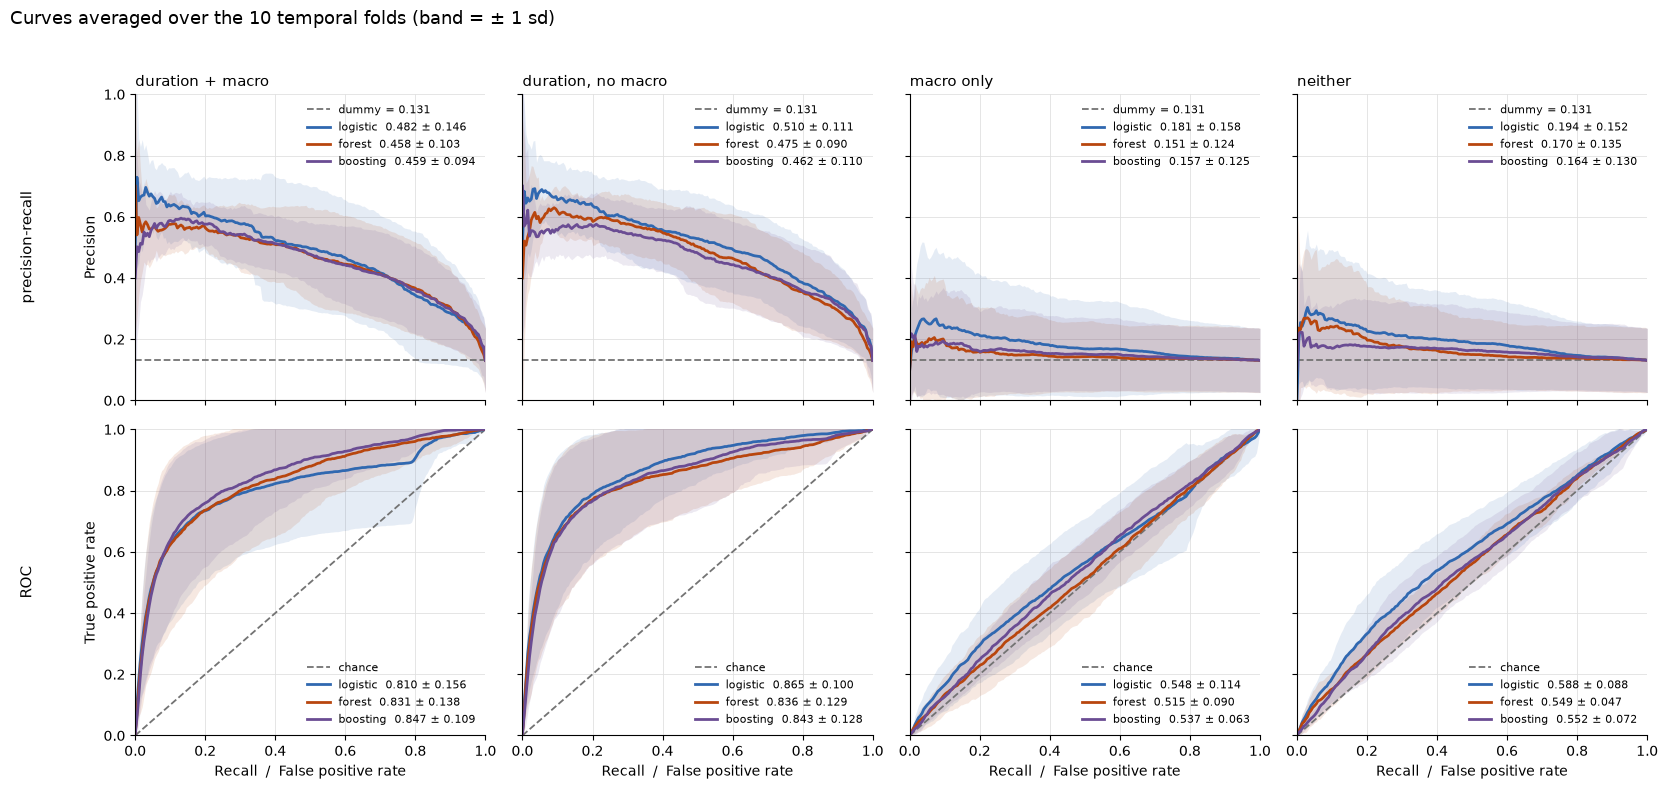

In [249]:
DURATION = ["duration"]
CLIENT_NUM = [c for c in NUMERICAL if c not in ECONOMIC + DURATION]

FEATURE_SETS = {
    "duration + macro":   CLIENT_NUM + DURATION + ECONOMIC,   #benchmark only
    "duration, no macro": CLIENT_NUM + DURATION,              #benchmark only
    "macro only":         CLIENT_NUM + ECONOMIC,              #deployable
    "neither":            CLIENT_NUM,                         #deployable
}
DEPLOYABLE = ["macro only", "neither"]

#Predictions are kept fold by fold, never concatenated: the models are trained on
#different amounts of data and their probability scales differ a lot between folds
#(fold 0 averages 0.84, fold 4 averages 0.03), so pooling them scrambles the ranking
#and gives an AUC that does not match the per-fold mean.
rows, curves = [], {}
for set_name, num in FEATURE_SETS.items():
    X = df[num + CATEGORICAL].iloc[idx_work]
    for model_name, pipe in build_models(num, CATEGORICAL).items():
        folds, roc, ap = [], [], []
        for tr, te in cv.split(X, y_work.to_numpy()):
            p = pipe.fit(X.iloc[tr], y_work.iloc[tr]).predict_proba(X.iloc[te])[:, 1]
            yt = y_work.iloc[te].to_numpy()
            folds.append((yt, p))
            roc.append(roc_auc_score(yt, p))
            ap.append(average_precision_score(yt, p))
        curves[(set_name, model_name)] = folds
        rows.append({"features": set_name, "model": model_name,
                     "baseline": np.mean([yt.mean() for yt, _ in folds]),
                     "ROC-AUC": np.mean(roc), "roc sd": np.std(roc, ddof=1),
                     "PR-AUC": np.mean(ap), "pr sd": np.std(ap, ddof=1)})

print(pd.DataFrame(rows).round(4).to_string(index=False))

#--- curves, averaged over the folds -----------------------------------------------
COLORS = {"logistic": "#3068b0", "forest": "#b8460e", "boosting": "#6a4c93"}
REF, GRID = "0.45", np.linspace(0, 1, 200)

fig, axes = plt.subplots(2, len(FEATURE_SETS), figsize=(4.2 * len(FEATURE_SETS), 8),
                         sharex=True, sharey=True)
for j, set_name in enumerate(FEATURE_SETS):
    base = np.mean([yt.mean() for yt, _ in curves[(set_name, "dummy")]])
    for row, kind in enumerate(("pr", "roc")):
        ax = axes[row, j]
        if kind == "pr":
            ax.axhline(base, color=REF, ls="--", lw=1.3, label=f"dummy = {base:.3f}")
        else:
            ax.plot([0, 1], [0, 1], color=REF, ls="--", lw=1.3, label="chance")

        for model in ("logistic", "forest", "boosting"):
            ys, aucs = [], []
            for yt, p in curves[(set_name, model)]:
                if kind == "pr":
                    pr, rc, _ = precision_recall_curve(yt, p)
                    #recall comes out high->low from sklearn: reverse before interpolating
                    ys.append(np.interp(GRID, rc[::-1], pr[::-1]))
                    aucs.append(average_precision_score(yt, p))
                else:
                    fpr, tpr, _ = roc_curve(yt, p)
                    ys.append(np.interp(GRID, fpr, tpr))
                    aucs.append(roc_auc_score(yt, p))
            ys = np.array(ys)
            m, s = ys.mean(axis=0), ys.std(axis=0, ddof=1)
            #the band is +-1 sd across the ten folds, not a confidence interval
            ax.fill_between(GRID, m - s, m + s, color=COLORS[model], alpha=0.12, lw=0)
            ax.plot(GRID, m, color=COLORS[model], lw=2,
                    label=f"{model}  {np.mean(aucs):.3f} ± {np.std(aucs, ddof=1):.3f}")
        if row == 1:
            ax.set_xlabel("Recall  /  False positive rate")
    axes[0, j].set_title(set_name, loc="left", fontsize=11)

axes[0, 0].set_ylabel("Precision")
axes[1, 0].set_ylabel("True positive rate")
for row, ax_row in enumerate(axes):
    for ax in ax_row:
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        #PR falls to the right, ROC rises to the left: legend goes in the empty corner
        ax.legend(frameon=False, fontsize=8,
                  loc="upper right" if row == 0 else "lower right")
        ax.grid(color="0.88", lw=0.6); ax.set_axisbelow(True)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
axes[0, 0].text(-0.33, 0.5, "precision-recall", transform=axes[0, 0].transAxes,
                rotation=90, va="center", fontsize=11)
axes[1, 0].text(-0.33, 0.5, "ROC", transform=axes[1, 0].transAxes,
                rotation=90, va="center", fontsize=11)
fig.suptitle("Curves averaged over the 10 temporal folds (band = ± 1 sd)",
             x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0.02, 0, 1, 0.96))
plt.show()

Two things come out of this table:

- **"duration"** outweighs the other twenty features together, massively improving ROC and precision-recall.
- **The macro features** does not seem to matter.

The best deployable combination on `neither`is the logistic regression, both for ROC and for precision-recall.

## 4.4 The test set

The model is refitted on the whole training set and applied to the test set, together
with two references: the dummy and the same model with the `duration` feature added.

In [ ]:
#Write...

## 4.5 Chronological split against random split

.....

In [ ]:
#Write....

# 5. Conclusions

# 6. Limits